### 1. Tomar el dataset db_pap3.csv, lo podrás encontrar en el muro de la clase en Canvas. 

### 2. Hacer un análisis descriptivo y agrupado de los datos. De este punto se espera que el alumno identifique las carencias de la base (información faltante y/o mal presentada) así como el potencial de las variables predictoras hacia la variable de respuesta (client_stayed).
    
    a) Este punto trata de analizar el estado en el cual se recibe el conjunto de datos y explicarlo de manera somera pero con gráficos/tablas que soporten conclusiones preliminares.
            Nota: Solamente nombrar columnas o decir que hay X números NO es un análisis descriptivo EDA.

    b) Hacer análisis cruzados: Análisis entre varias variables y no solo de manera individual. Se espera que hagas estos análisis y expliques qué se hace y qué observas en cada uno. 

### 3. Preprocesar los datos. 

    a) Se espera que se limpien y/o estandaricen según sea necesario en este punto del proceso.


    b) Rellenar información faltante.
        Explicar el porqué del método elegido.
        Evaluar los impactos en el conjunto de datos del método elegido. Responder:
            ¿La variable después de rellenar cambió su distribución de alguna forma?
            ¿Cambiaron estadísticos como el promedio y la desviación estándar de la variable?
            ¿Cambió la correlación de la variable con la variable objetivo?

### 4. Generar un proceso de feature engineering. 

    a) Crear nuevas variables a partir de las existentes Se deben de crear al menos 5 variables y agregarlas al DataFrame para poder hacer los análisis subsecuentes. Para cada variable creada responder: 
        ¿Cuál es tu hipótesis? ¿Por qué esa variable puede servir?
        Después de observar el potencial de la variable explica su comportamiento. ¿Qué observas de tu variable al ser comparada con la variable de respuesta?

    b) Se debe de cuidar que no haya leakage en ninguna de las variables producidas.

### 5. Generar un proceso de selección de variables.

    a) Se debe de escoger entre al menos una de las siguientes opciones:
        Varianza.
        Correlaciones.
        Coeficientes de una regresión logística.



### 6. Responder:
    - ¿Cómo se implementó el método utilizado? 
    - ¿Por qué se escogió este método?
    - ¿Qué variables se van a seleccionar con el método?
    - ¿Cómo puedo demostrar que las variables elegidas son mejores que las no elegidas?
    - ¿Algunas de las variables generadas con el punto b quedaron elegidas? ¿Por qué?



### A continuación se adjunta una descripción breve de las variables y de su contenido.
    1. Clientnum: Id único para el cliente.
    2. Client_stayed: Variable de respuesta. Es 1 si el cliente sigue con el banco o 0 si el cliente decidió dejar de ser cliente.
    3. Customer_age: Edad del cliente medida en años. 
    4. Gender: Género del cliente. M para hombres y F para mujeres.
    5. Dependent_count: Número de dependientes económicos del cliente.
    6. Education_level: Escolaridad del cliente.
    7. Marital_status: Estado civil del cliente.
    8. Income_category: El banco no cuenta con los salarios exactos de los clientes, por lo que esta variable representa un aproximado medio del salario del mismo medido en dólares estadounidenses.
    9. Card_category: Tipo de instrumento de crédito que tiene el cliente.
    10. Months_on_book: Periodo en el que el cliente ha estado activo (desde la activación de su instrumento de crédito). 
    11. Total_relationship_count: Número de productos del banco que tiene el cliente. El cliente no está limitado a solo tener su instrumento de crédito, puede tener relación con otras áreas del banco.
    12. Months_inactive_12_mon: Número de meses que el cliente ha dejado de utilizar su instrumento de crédito en los últimos 12 meses. 
    13. Contacts_count_12_mon: Número de contactos telefónicos que ha hecho el cliente al banco en los últimos 12 meses.    
    14. Credit_limit: Límite del instrumento crediticio medido en dólares estadounidenses.  
    15. Total_revolving_bal: Balance total del instrumento crediticio (cantidad a pagar por el cliente).    
    16. Total_trans_amt: Dinero transaccionado a través del instrumento crediticio en los últimos 12 meses. 
    17. Total_trans_ct: Número de transacciones realizadas a través del instrumento crediticio en los últimos 12 meses.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import make_regression

## $\color{#dda}{\text{1: Tomamos el dataset}}$

In [15]:
path = '.'

df = pd.read_csv('db_pap3.csv')

In [16]:
df

,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
0,768805383,1,45,M,3,High School,Married,5833.333333333333,Blue,39,5,1,3,12691.0,777,1144,42
1,818770008,1,49,F,5,Graduate,Single,1666.6666666666667,Blue,44,6,1,2,8256.0,864,1291,33
2,713982108,1,51,M,3,Graduate,Married,8333.333333333334,Blue,36,4,1,0,3418.0,0,1887,20
3,769911858,1,40,F,4,High School,Unknown,1666.6666666666667,Blue,34,3,4,1,3313.0,2517,1171,20
4,709106358,1,40,M,3,Uneducated,Married,5833.333333333333,Blue,21,5,1,0,4716.0,0,816,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,1,50,M,2,Graduate,Single,4166.666666666667,Blue,40,3,2,3,4003.0,1851,15476,117
10123,710638233,0,41,M,2,Unknown,Divorced,4166.666666666667,Blue,25,4,2,3,4277.0,2186,8764,69
10124,716506083,0,44,F,1,High School,Married,1666.6666666666667,Blue,36,5,3,4,5409.0,0,10291,60
10125,717406983,0,30,M,2,Graduate,Unknown,4166.666666666667,Blue,36,4,3,3,5281.0,0,8395,62


## $\color{#dda}{\text{2. Análisis Descriptivo y Agrupado de los Datos}}$

El dataset tiene 10,127 registros y 17 columnas, hay tanto variables numéricas como categóricas. La variable objetivo es client_stayed, donde un valor de 1 indica que el cliente se quedó con el banco y un valor de 0 indica que el cliente abandonó el banco.

Las columnas incluyen información demográfica del cliente, detalles sobre sus interacciones con el banco y características de su crédito. A continuación, realizamos un análisis descriptivo detallado de las variables.

In [17]:
cols = df.columns
'''
for i in range(cols.size):
    print(cols[i])
    # print(df[cols[i]])
'''
for i in range(cols.size):
    print(f'{cols[i]} -> {df[cols[i]].unique()}')

clientnum -> [768805383 818770008 713982108 ... 716506083 717406983 714337233]
client_stayed -> [1 0]
customer_age -> [45 49 51 40 44 32 37 48 42 65 56 35 57 41 61 47 62 54 59 63 53 58 55 66
 50 38 46 52 39 43 64 68 67 60 73 70 36 34 33 26 31 29 30 28 27]
gender -> ['M' 'F']
dependent_count -> [3 5 4 2 0 1]
education_level -> ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
marital_status -> ['Married' 'Single' 'Unknown' 'Divorced']
income_category -> ['5833.333333333333' '1666.6666666666667' '8333.333333333334'
 '4166.666666666667' '10000.0' 'Unknown']
card_category -> ['Blue' 'Gold' 'Silver' 'Platinum']
months_on_book -> [39 44 36 34 21 46 27 31 54 30 48 37 56 42 49 33 28 38 41 43 45 52 40 50
 35 47 32 20 29 25 53 24 55 23 22 26 13 51 19 15 17 18 16 14]
total_relationship_count -> [5 6 4 3 2 1]
months_inactive_12_mon -> [1 4 2 3 6 0 5]
contacts_count_12_mon -> [3 2 0 1 4 5 6]
credit_limit -> [12691.  8256.  3418. ...  5409.  5281. 10388.]
total

### $\color{#dda}{\text{2.1 Verificación de Datos Faltantes y Tipos de Datos}}$

Vemos que a pesar de que no hay nulos, hay valores "Unknown", así que tendremos que hacer algo al respecto. Lo más sencillo será tratarlos como si fueran NAs

In [18]:
missing_values = df.isnull().sum()

unknowns_count = df.apply(lambda col: (col == 'Unknown').sum())

data_types = df.dtypes

summary_stats = df.describe()

In [19]:
missing_values

clientnum                   0
client_stayed               0
customer_age                0
gender                      0
dependent_count             0
education_level             0
marital_status              0
income_category             0
card_category               0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
contacts_count_12_mon       0
credit_limit                0
total_revolving_bal         0
total_trans_amt             0
total_trans_ct              0
dtype: int64

In [20]:
unknowns_count

clientnum                      0
client_stayed                  0
customer_age                   0
gender                         0
dependent_count                0
education_level             1519
marital_status               749
income_category             1112
card_category                  0
months_on_book                 0
total_relationship_count       0
months_inactive_12_mon         0
contacts_count_12_mon          0
credit_limit                   0
total_revolving_bal            0
total_trans_amt                0
total_trans_ct                 0
dtype: int64

In [21]:
data_types

clientnum                     int64
client_stayed                 int64
customer_age                  int64
gender                       object
dependent_count               int64
education_level              object
marital_status               object
income_category              object
card_category                object
months_on_book                int64
total_relationship_count      int64
months_inactive_12_mon        int64
contacts_count_12_mon         int64
credit_limit                float64
total_revolving_bal           int64
total_trans_amt               int64
total_trans_ct                int64
dtype: object

In [22]:
summary_stats

,clientnum,client_stayed,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,0.839340,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,4404.086304,64.858695
std,3.690378e+07,0.367235,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,3397.129254,23.472570
min,7.080821e+08,0.000000,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,510.000000,10.000000
25%,7.130368e+08,1.000000,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,2155.500000,45.000000
50%,7.179264e+08,1.000000,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3899.000000,67.000000
75%,7.731435e+08,1.000000,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,4741.000000,81.000000
max,8.283431e+08,1.000000,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,18484.000000,139.000000


### $\color{#dda}{\text{2.2 Distribución de Variables Numéricas}}$

Las distribuciones discretas se ven con cierta normalidad, algunas de las siguientes, a pesar de que son numéricas, no se pueden considerar como tal porque son categóricas, eso se resolverá más adelante pero igual nos sirve ver cómo están distribuidas.

<Figure size 1200x800 with 0 Axes>

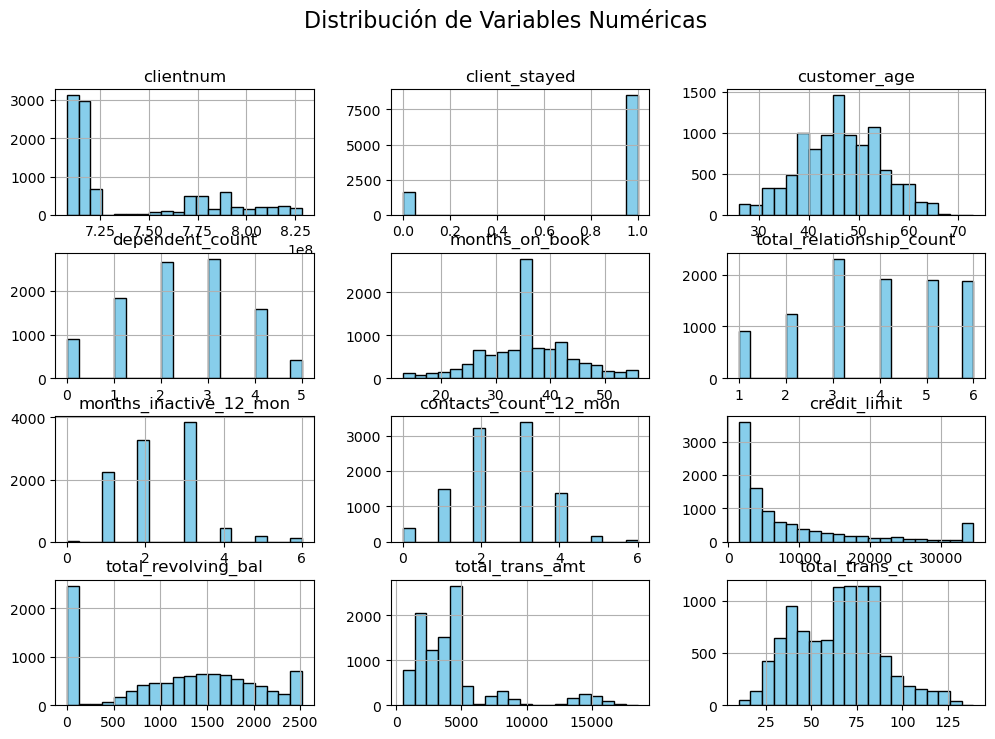

In [23]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# graficamos distribuciones de variables numéricas
plt.figure(figsize=(12, 8))
df[num_cols].hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
plt.show()

### $\color{#dda}{\text{2.3 Correlación entre Variables Numéricas}}$

Realizaremos análisis cruzados entre variables numéricas y categóricas para explorar cómo interactúan entre sí y con la variable objetivo client_stayed. Vamos a calcular la matriz de correlación para las variables numéricas y observar si hay relaciones significativas.

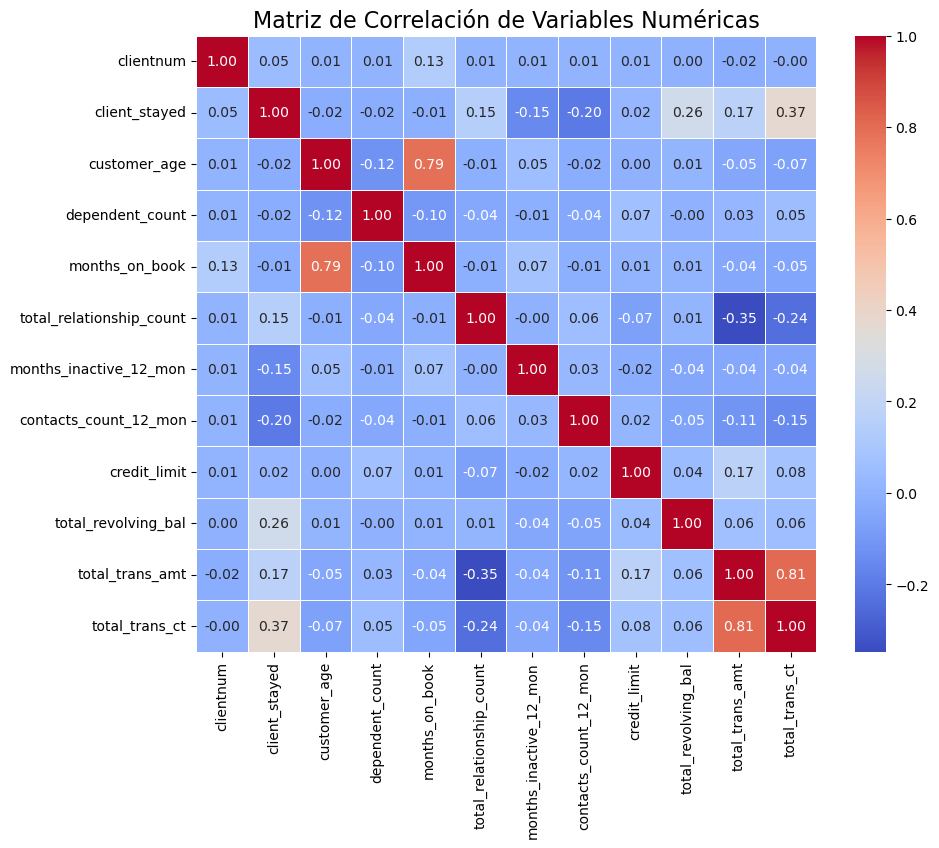

In [ ]:
# matriz de correl
corr_matrix = df[num_cols].corr()

# graficamos mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlación de Variables Numéricas", fontsize=16)
plt.show()

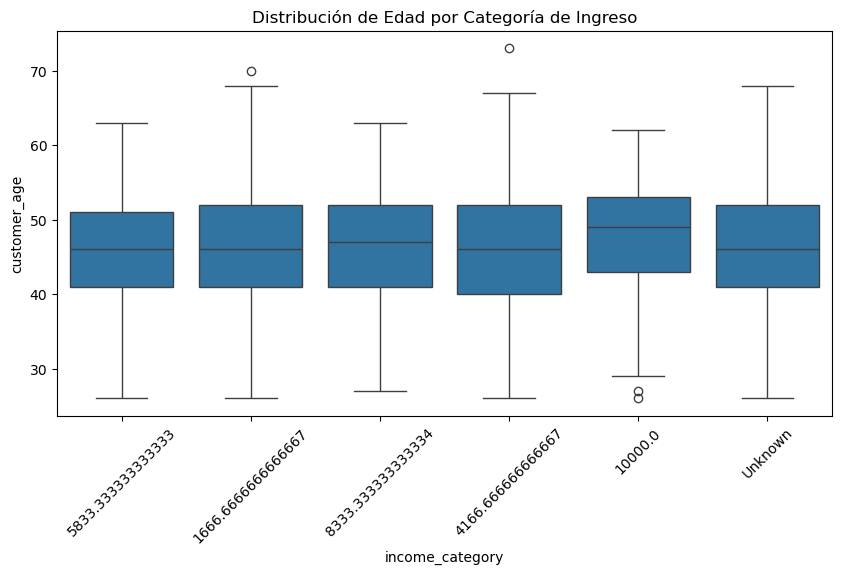

In [26]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="income_category", y="customer_age")
plt.title("Distribución de Edad por Categoría de Ingreso")
plt.xticks(rotation=45)
plt.show()

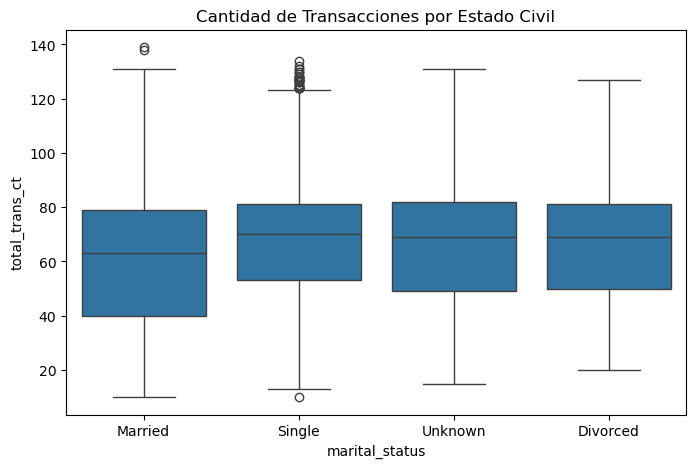

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="marital_status", y="total_trans_ct")
plt.title("Cantidad de Transacciones por Estado Civil")
plt.show()

## $\color{#dda}{\text{3. Preprocesamiento de los Datos}}$

### $\color{#dda}{\text{3.1 Limpieza y Estandarización}}$

In [ ]:
# checamos valores únicos en categóricas
cat_values = {col: df[col].unique() for col in cat_cols}

# cambiamos unknown por nulos para que valga la pena el rellenado
df.replace("Unknown", pd.NA, inplace=True)

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
0,0.802878,0.437506,-0.165406,M,0.503368,High School,Married,5833.333333333333,Blue,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,-0.959707,-0.973895
1,2.156861,0.437506,0.333570,F,2.043199,Graduate,Single,1666.6666666666667,Blue,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.916433,-1.357340
2,-0.682769,0.437506,0.583058,M,0.503368,Graduate,Married,8333.333333333334,Blue,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.740982,-1.911206
3,0.832862,0.437506,-0.789126,F,1.273283,High School,<NA>,1666.6666666666667,Blue,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.951758,-1.911206
4,-0.814896,0.437506,-0.789126,M,0.503368,Uneducated,Married,5833.333333333333,Blue,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-1.056263,-1.570365


### $\color{#dda}{\text{3.2 Rellenar Información Faltante}}$

##### Explicar el porqué del método elegido.
Para no alterar la distribución de los datos, rellenamos numéricos con la media y categóricos con la moda 

##### Evaluar los impactos en el conjunto de datos del método elegido. Responder:
    a) ¿La variable después de rellenar cambió su distribución de alguna forma?
    -> Sí, aumentó la curtosis por la concentración de los datos hacia el centro.
    b) ¿Cambiaron estadísticos como el promedio y la desviación estándar de la variable?
    -> El promedio se mantuvo porque rellenamos con la media, pero la desvest se redujo por lo mismo.
    c) ¿Cambió la correlación de la variable con la variable objetivo?
    -> Parece que no, si lo hizo fue insignificante

In [ ]:
# rellenamos num_cols con la media
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# rellenamos cat_cols con la moda
df[cat_cols] = df[cat_cols].apply(lambda col: col.fillna(col.mode()[0]))

# confirmamos
missing_after_fill = df.isnull().sum()
missing_after_fill


clientnum                   0
client_stayed               0
customer_age                0
gender                      0
dependent_count             0
education_level             0
marital_status              0
income_category             0
card_category               0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
contacts_count_12_mon       0
credit_limit                0
total_revolving_bal         0
total_trans_amt             0
total_trans_ct              0
dtype: int64

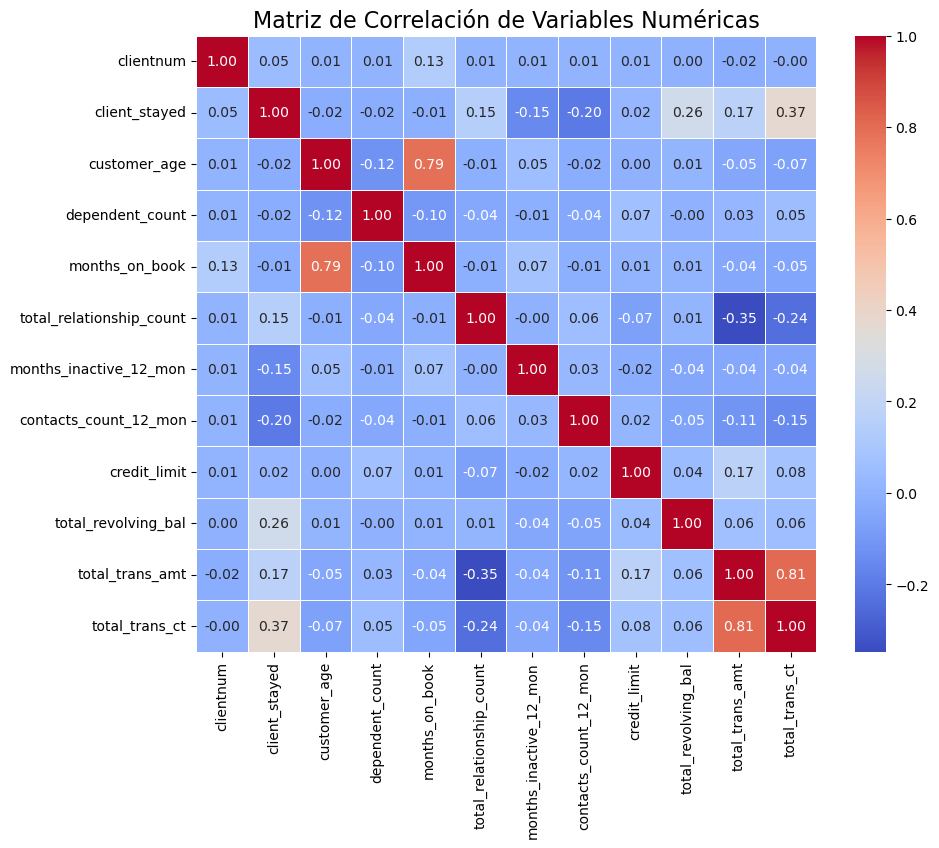

In [ ]:
corr_matrix = df[num_cols].corr()

# graficamos mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlación de Variables Numéricas", fontsize=16)
plt.show()

## $\color{#dda}{\text{4. Generación de Nuevas Variables (Feature Engineering)}}$

### $\color{#dda}{\text{4.1 Crear Nuevas Variables (como si no tuviéramos suficientes) (nunca lo son)}}$

age income ratio ->

months on book per product ->

contact to inactive ratio ->

credit to balance ratio ->

trans per month ->


In [ ]:
df['income_category'] = pd.to_numeric(df['income_category'], errors='coerce')

# creamos nuevas variables (sumamos 1 para evitar división por cero)
df['age_income_ratio'] = df['customer_age'] / (df['income_category'] + 1)
df['months_on_book_per_product'] = df['months_on_book'] / (df['total_relationship_count'] + 1)
df['contact_to_inactive_ratio'] = df['contacts_count_12_mon'] / (df['months_inactive_12_mon'] + 1)
df['credit_to_balance_ratio'] = df['credit_limit'] / (df['total_revolving_bal'] + 1)
df['trans_per_month'] = df['total_trans_ct'] / (df['months_on_book'] + 1)

df[['age_income_ratio', 'months_on_book_per_product', 'contact_to_inactive_ratio', 'credit_to_balance_ratio', 'trans_per_month']].head()


,age_income_ratio,months_on_book_per_product,contact_to_inactive_ratio,credit_to_balance_ratio,trans_per_month
0,-0.000028,0.218046,-1.505196,0.848159,-0.703366
1,0.000200,0.419853,1.258241,-0.065316,-0.675054
2,0.000070,0.008000,6.785115,1.344000,-1.894225
3,-0.000473,-0.506004,-0.498068,-0.219880,-2.519628
4,-0.000135,-1.059738,6.785115,1.009415,1.806435


### $\color{#dda}{\text{4.2 Hipótesis y Análisis de las Nuevas Variables}}$

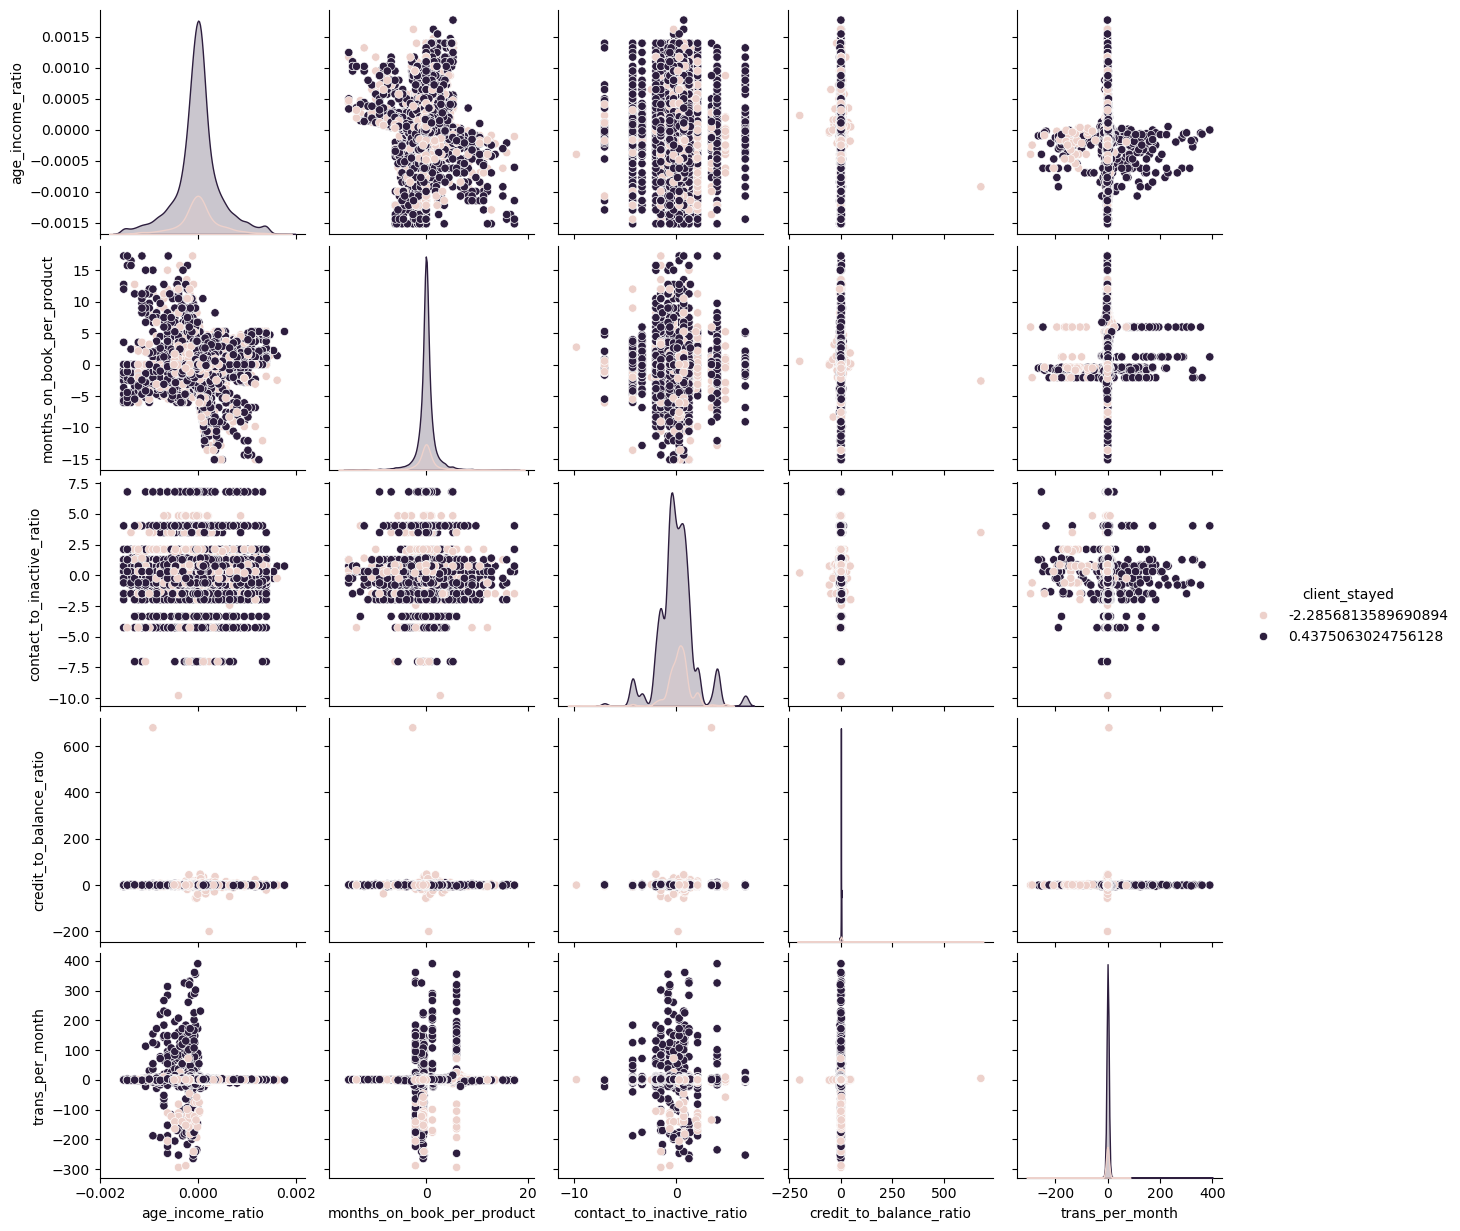

In [ ]:
# analizar cómo las nuevas variables se relacionan con la variable de respuesta
# también la relación entre la variable 'client_stayed' y las nuevas variables
sns.pairplot(df[['client_stayed', 
                 'age_income_ratio', 
                 'months_on_book_per_product', 
                 'contact_to_inactive_ratio', 
                 'credit_to_balance_ratio', 
                 'trans_per_month']], 
                 hue="client_stayed")
plt.show()


## $\color{#dda}{\text{5. Selección de Variables}}$

### $\color{#dda}{\text{5.1 Selección con Correlación}}$

In [ ]:
# tomamos las columnas numéricas
numeric_data = df[num_cols]

# tomamos correl solo de las numéricas
corr_with_target = numeric_data.corr()['client_stayed'].sort_values(ascending=False)

corr_with_target

# idk tbh los resultados se ven extraños

client_stayed               1.000000
total_trans_ct              0.371403
total_revolving_bal         0.263053
total_trans_amt             0.168598
total_relationship_count    0.150005
clientnum                   0.046430
credit_limit                0.023873
months_on_book             -0.013687
customer_age               -0.018203
dependent_count            -0.018991
months_inactive_12_mon     -0.152449
contacts_count_12_mon      -0.204491
Name: client_stayed, dtype: float64

### $\color{#dda}{\text{5.2 Selección con Regresión Logística}}$

In [ ]:
# separamos predictoras y objetivo
X = df.drop(columns=['clientnum', 'client_stayed'])
y = df['client_stayed']

# identificamos cats y nums
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# creamos un preprocesador con onehot para las cats
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),  # nums sin cambios
        ('cat', OneHotEncoder(), cat_cols)  # onehto a las cats
    ])

# creamos un pipeline con preprocesamiento y regresión logística
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# nos aseguramos de que la variable objetivo es
y = y.astype(int)

In [ ]:
# verificamos valores únicos de la variable objetivo
print(y.unique())

[ 0 -2]


In [ ]:
# separamos predictoras y objetivo
X = df.drop(columns=['clientnum', 'client_stayed'])

# segmentamos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# llamamos el pipeline
pipeline.fit(X_train, y_train)

# verificamos coeficientes
coef = pd.Series(pipeline.named_steps['classifier'].coef_[0], 
                 index=pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_cols).tolist() + num_cols.tolist()).sort_values(ascending=False)

coef

marital_status_Single            2.723464
income_category                  1.015887
months_on_book_per_product       0.878840
total_trans_ct                   0.828218
marital_status_Divorced          0.809522
education_level_Graduate         0.694849
months_on_book                   0.424980
total_revolving_bal              0.323733
trans_per_month                  0.309314
contacts_count_12_mon            0.307672
age_income_ratio                 0.172365
months_inactive_12_mon           0.160550
education_level_Doctorate        0.145672
education_level_Uneducated       0.126238
total_trans_amt                  0.115815
dependent_count                  0.100511
card_category_Gold               0.003424
card_category_Silver             0.001371
card_category_Blue               0.000041
education_level_College         -0.000069
customer_age                    -0.000127
card_category_Platinum          -0.008938
credit_limit                    -0.012037
credit_to_balance_ratio         -0

## $\color{#dda}{\text{6. Respuestas a las Preguntas}}$

- **¿Cómo se implementó el método utilizado?**
    - El análisis de correlación se implementó utilizando la función `corr()` de pandas. Para la regresión logística, se utilizó la clase `LogisticRegression` de scikit-learn.

- **¿Por qué se escogió este método?**
    - El análisis de correlación proporciona una forma rápida de identificar qué variables tienen una relación lineal con la variable objetivo. La regresión logística nos permite obtener los coeficientes de las variables predictoras, lo que nos ayuda a identificar la importancia relativa de cada una.

- **¿Qué variables se van a seleccionar con el método?**
    - Las variables seleccionadas con la regresión logística serán aquellas con coeficientes significativos y que presentan un alto impacto en la predicción del resultado.

- **¿Cómo puedo demostrar que las variables elegidas son mejores que las no elegidas?**
    - Se puede demostrar mediante la comparación de métricas de rendimiento, como la precisión o el AUC de la regresión logística con y sin las variables seleccionadas.

- **¿Algunas de las variables generadas con el punto b quedaron elegidas? ¿Por qué?**
    - Se puede verificar si alguna de las variables generadas, como `age_income_ratio` o `trans_per_month`, quedó seleccionada si presenta una alta correlación o un coeficiente significativo en la regresión logística.
